In [ ]:
# %pip install google-api-python-client google-auth-httplib2 google-auth-oauthlib langchain langchain-community langchain-openai langgraph
# %pip install transformers accelerate bitsandbytes
# %pip install torch --index-url https://download.pytorch.org/whl/cu125
# %pip install graphviz

In [1]:
import os

from langchain_community.utilities import GoogleSearchAPIWrapper
from langgraph.graph import StateGraph, END
from dotenv import load_dotenv

from google.oauth2.credentials import Credentials
from googleapiclient.discovery import build
from google.auth.transport.requests import Request

from dataclasses import dataclass, field
from typing import List, Dict, Any
from typing import Optional

from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
import time

# Load environment variables from .env file
load_dotenv()  # for GOOGLE_API_KEY, GOOGLE_CSE_ID



False

In [2]:
# --- Load LLaMA model and tokenizer ---
def load_llama_model(model_name="meta-llama/Llama-3.2-1B-Instruct", device="cpu"):
    tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
    model = AutoModelForCausalLM.from_pretrained(model_name, torch_dtype=torch.float16).to(device)
    config = model.config
    print("Loaded model:", model_name)
    
    return model, config, tokenizer

# -- Load model and prepare block --
device = 'cuda'  # if supported
# device = 'cpu'  # default device
model, config, tokenizer = load_llama_model(device=device)  # load the entire model



Loaded model: meta-llama/Llama-3.2-1B-Instruct


In [23]:
def llama_chat(prompt: str) -> str:
    start = time.time()
    messages = [
        {"role": "system", "content": "You are a helpful assistant."},
        {"role": "user", "content": prompt}
    ]
    prompt_text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    # print("Prompt text:", prompt_text)
    inputs = tokenizer(prompt_text, return_tensors="pt").to(model.device)
    model.eval()
    with torch.no_grad():
        output = model.generate(**inputs, max_new_tokens=512, eos_token_id=tokenizer.eos_token_id,
            do_sample=True, temperature=0.7,top_p=0.9)

    print("Response time:", time.time() - start)
    return tokenizer.decode(output[0], skip_special_tokens=True)



In [4]:
# --- 1. Define the Agent State ---
@dataclass
class AgentState:
    user_query: str
    relevant_emails: List[Dict[str, Any]] = field(default_factory=list)
    search_results: List[str] = field(default_factory=list)
    extracted_info: Dict[str, Any] = field(default_factory=dict)
    refined_query: str = ""
    steps_taken: List[str] = field(default_factory=list)

In [5]:
# --- 2. Define the Nodes (Steps) in Your Graph ---
def get_user_query(state: AgentState) -> Dict:
    return {"user_query": state.user_query}

def search_emails(state: AgentState) -> Dict:
    print("Searching emails using Gmail API...")
    start = time.time()
    try:
        creds = None
        if os.path.exists('token.json'):
            creds = Credentials.from_authorized_user_file('token.json', ['https://www.googleapis.com/auth/gmail.readonly'])
        if not creds or not creds.valid:
            if creds and creds.expired and creds.refresh_token:
                creds.refresh(Request())
            else:
                from google_auth_oauthlib.flow import InstalledAppFlow
                flow = InstalledAppFlow.from_client_secrets_file(
                    'credentials.json', ['https://www.googleapis.com/auth/gmail.readonly'])
                creds = flow.run_local_server(port=0)
            with open('token.json', 'w') as token:
                token.write(creds.to_json())

        service = build('gmail', 'v1', credentials=creds)

        query = state.refined_query if state.refined_query else state.user_query
        search_results = service.users().messages().list(userId='me', q=query).execute()
        messages = search_results.get('messages', [])

        relevant_emails = []
        for message in messages:
            msg = service.users().messages().get(userId='me', id=message['id'], format='metadata', metadataHeaders=['From', 'Subject', 'Date']).execute()
            headers = msg.get('payload').get('headers')
            sender = next((header['value'] for header in headers if header['name'] == 'From'), 'N/A')
            subject = next((header['value'] for header in headers if header['name'] == 'Subject'), 'N/A')
            date = next((header['value'] for header in headers if header['name'] == 'Date'), 'N/A')
            snippet = msg.get('snippet', '')
            relevant_emails.append({"sender": sender, "subject": subject, "body_snippet": snippet, "date": date})
        print("Gmail Searching time:", time.time() - start)
        return {"relevant_emails": relevant_emails}

    except Exception as error:
        print("Gmail Searching time:", time.time() - start)
        print(f'An error occurred: {error}')
        return {"relevant_emails": []}

def analyze_emails(state: AgentState) -> Dict:
    print("Analyzing emails with LLaMA...")
    start = time.time()
    context = "\n".join([
        f"Sender: {email['sender']}, Subject: {email['subject']}, Snippet: {email['body_snippet']}, Date: {email['date']}"
        for email in state.relevant_emails
    ])
    prompt = f"""Based on the following email snippets:
{context}

Given the original user query: \"{state.user_query}\", identify the most likely email(s) the user is looking for.
Explain your reasoning briefly. If no relevant emails are found, state that clearly.

Provide the sender, subject, and a short summary of the most relevant email(s).
"""
    response = llama_chat(prompt)
    print("LLaMA Analysis time:", time.time() - start)
    print(f"LLaMA Analysis: {response}")
    return {"extracted_info": {"analysis": response, "relevant_emails": state.relevant_emails}}

def web_search(state: AgentState) -> Dict:
    print("Performing web search...")
    start = time.time()
    search = GoogleSearchAPIWrapper(google_api_key=os.getenv("GOOGLE_API_KEY"), google_cse_id=os.getenv("GOOGLE_CSE_ID"))
    results = search.run(f"site:linkedin.com people {state.user_query}")
    print("Web Search time:", time.time() - start)
    print(f"Web Search Results: {results[:3]}")
    return {"search_results": results[:3]}

def refine_query(state: AgentState) -> Dict:
    print("Refining search query with LLaMA...")
    start = time.time()
    prompt = f"""The user's original query was: \"{state.user_query}\".
Based on the initial email search results (if any: {state.relevant_emails}) and potentially web search results ({state.search_results}),
suggest a more specific query to find the desired email. Consider keywords, date ranges, and potential sender information.
Provide only the refined search query.
"""
    response = llama_chat(prompt)
    print("LLaMA Refinement time:", time.time() - start)
    print(f"LLaMA Refinement: {response}")
    return {"refined_query": response.strip()}



In [6]:
# --- 3. Define the Edges (Transitions) Between Nodes ---
def should_refine(state: AgentState):
    if not state.relevant_emails:
        return "refine"
    elif len(state.relevant_emails) > 5:
        return "refine"
    else:
        return "analyze"

def should_web_search(state: AgentState):
    if not state.extracted_info and not state.search_results:
        return "web_search"
    else:
        return "analyze"



In [36]:
# --- 4. Build the LangGraph ---
builder = StateGraph(AgentState)
builder.add_node("get_query", get_user_query)
builder.add_node("search_emails", search_emails)
builder.add_node("analyze_emails", analyze_emails)
builder.add_node("refine_query", refine_query)
builder.add_node("web_search", web_search)

builder.set_entry_point("get_query")

builder.add_edge("get_query", "search_emails")
builder.add_conditional_edges("search_emails", should_refine, {"refine": "refine_query", "analyze": "analyze_emails"})
builder.add_edge("refine_query", "search_emails")
builder.add_conditional_edges("analyze_emails", should_web_search, {"web_search": "web_search", END: END})
builder.add_edge("web_search", "analyze_emails")
builder.add_edge("analyze_emails", END)

graph = builder.compile()



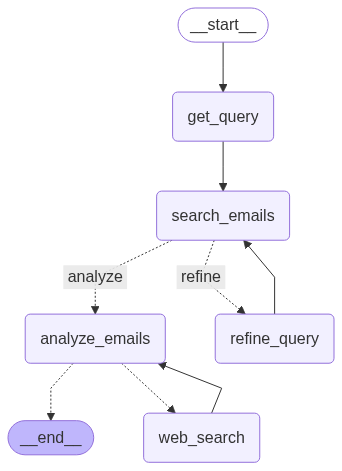

In [ ]:
from IPython.display import display  # for Jupyter Notebook only

# Generate and display PNG
png_data = graph.get_graph().draw_mermaid_png()
display(Image(png_data))  # for Jupyter Notebook only
with open("graph.png", "wb") as f:
    f.write(png_data)

In [ ]:
# --- 5. Run the Agent ---

if __name__ == "__main__":
    # -- Load model and prepare block --
    device = 'cuda'  # if supported
    # device = 'cpu'  # default device
    model, config, tokenizer = load_llama_model(device=device)  # load the entire model

    user_input = input("Describe the email you're looking for: ")
    result = graph.invoke({"user_query": user_input})
    print("\n--- Final Result ---")
    print(result["extracted_info"]["analysis"])
    if result.get("extracted_info") and result["extracted_info"].get("relevant_emails"):
        print("\nRelevant Emails:")
        for email in result["extracted_info"]["relevant_emails"]:
            print(f"  Sender: {email.get('sender')}, Subject: {email.get('subject')}, Date: {email.get('date')}")
    if result.get("search_results"):
        print("\nWeb Search Results:")
        for res in result["search_results"]:
            print(f"- {res}")

In [21]:

response = llama_chat("Is Sacramento the capital of California?")
print("LLaMA Response:", response)

Setting `pad_token_id` to `eos_token_id`:128009 for open-end generation.


Response time: 0.6231689453125
LLaMA Response: system

Cutting Knowledge Date: December 2023
Today Date: 22 May 2025

You are a helpful assistant.user

Is Sacramento the capital of California?assistant

No, Sacramento is not the capital of California. The capital of California is actually Sacramento.
